In [1]:
# !pip install pytrends
# !pip install nltk

In [2]:
# Import neccessary libraries

import pandas as pd
import numpy as np
import re
import time
import matplotlib.pyplot as plt
import pytrends
import seaborn as sns

from pytrends.request import TrendReq
# import nltk

pd.set_option('future.no_silent_downcasting', True)
sns.set()

In [3]:
# nltk.download("punkt")
# nltk.download("punkt_tab")

### Fetching and Comparing Interest Over Time

In [4]:
pytrends = TrendReq(hl="en-US", tz=60) # Initialize TrendReq()

keywords = ["DANGOTE CEMENT", "GUARANTY TRUST BANK", "ZENITH BANK"]

timeframe = "today 5-y" # "today 12-m"

# pytrends.build_payload(kw_list=keywords, timeframe=timeframe)
pytrends.build_payload(kw_list=keywords, timeframe=timeframe, geo="NG") # Set to Nigeria Geographical Area

interest_over_time_df = pytrends.interest_over_time()
# interest_over_time_df = interest_over_time_df.fillna(False)
interest_over_time_df.query("isPartial == False", inplace=True)

n = len(interest_over_time_df.columns) # Numeber of Columns
interest_over_time_df = interest_over_time_df.iloc[:, :n-1]
interest_over_time_df.to_csv("../outputs/SVI_Interest_Over_Time_NG.csv", sep=",")

In [5]:
interest_over_time_df.head() # Overview of the dataset

,DANGOTE CEMENT,GUARANTY TRUST BANK,ZENITH BANK
date,,,
2021-08-01,1,1,31
2021-08-08,1,1,27
2021-08-15,1,1,27
2021-08-22,1,1,26
2021-08-29,1,1,34


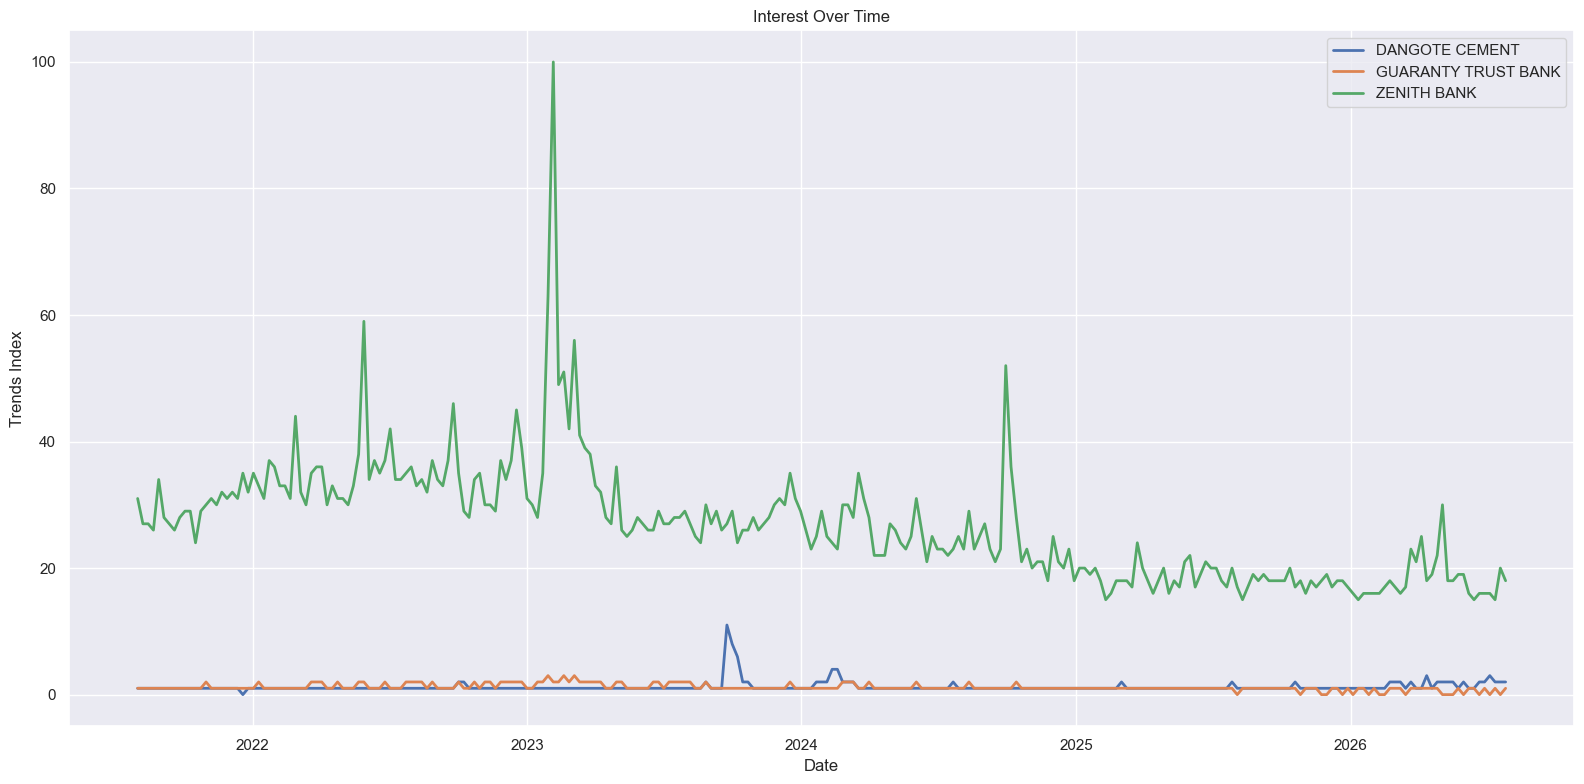

In [6]:
# Plotting the interest over time
plt.figure(figsize=(16, 8))
for keyword in keywords:
    sns.lineplot(
        x=interest_over_time_df.index, 
        y=interest_over_time_df[keyword],
        label = keyword,
        linewidth=2
    )
plt.xlabel("Date")
plt.ylabel("Trends Index")
plt.title("Interest Over Time")
plt.legend(loc="upper right")
plt.grid(True)
plt.tight_layout()
plt.savefig("../outputs/SVI_Interest_Over_Time_NG.png", dpi=300, bbox_inches="tight")
plt.show()

In [7]:
avg_SVI = interest_over_time_df.mean()  # Average SVI
std_SVI = interest_over_time_df.std()   # Std Dev SVI
max_SVI = interest_over_time_df.max()   # Maximum SVI
min_SVI = interest_over_time_df.min()   # Minimum SVI

summary_stats = pd.DataFrame({
    "Keyword": interest_over_time_df.columns,
    "Mean SVI": avg_SVI,
    "Std Dev SVI": std_SVI,
    "Max SVI (Peak)": max_SVI,
    "Min SVI": min_SVI
})
# summary["Average SVI"] = avg_SVI
# summary["Standard Deviation SVI"] = std_SVI
summary_stats.reset_index(drop=True, inplace=True)
summary_stats.to_csv("../outputs/SVI_Summary_Statistics.csv")
print("Summary Statistics for Search Volume Index:")
display(summary_stats)

Summary Statistics for Search Volume Index:


,Keyword,Mean SVI,Std Dev SVI,Max SVI (Peak),Min SVI
0,DANGOTE CEMENT,1.229885,0.911902,11,0
1,GUARANTY TRUST BANK,1.153257,0.533024,3,0
2,ZENITH BANK,26.808429,9.404259,100,15


#### Correlation of Each Keywords

In [8]:
##K Keywords Correlations
corr_interest_over_time = interest_over_time_df.corr()
corr_interest_over_time.to_csv("../outputs/SVI_Corr_Interest_Over_Time_NG.csv", sep=",")
corr_interest_over_time

,DANGOTE CEMENT,GUARANTY TRUST BANK,ZENITH BANK
DANGOTE CEMENT,1.000000,-0.096500,-0.082749
GUARANTY TRUST BANK,-0.096500,1.000000,0.576738
ZENITH BANK,-0.082749,0.576738,1.000000


**Interest Over Time:**

> The Google Trends data shows that **Zenith Bank consistently dominates search interest in Nigeria** compared to Dangote Cement and Guaranty Trust Bank. From 2021 to 2026, Zenith Bank’s trend line remains significantly higher, with noticeable peaks that suggest periods of heightened public attention—likely tied to product launches, service issues, or major announcements. In contrast, Dangote Cement and Guaranty Trust Bank maintain relatively low and stable search volumes, indicating less frequent spikes in public interest.

This suggests that **consumer-facing financial institutions attract more consistent online attention** than industrial companies like Dangote Cement, which may only trend during specific events (e.g., corporate news or policy changes).

### Analyzing Interest by Region

In [9]:
pytrends.build_payload(kw_list=keywords, timeframe=timeframe, geo="NG")  # Set to Nigeria Geographical Area
interest_by_region_df = pytrends.interest_by_region()
interest_by_region_df.index.name = "REGION"
interest_by_region_df.to_csv("../outputs/SVI_Interest_By_Region_NG.csv", sep=",")

#### Sort by DANGOTE CEMENT

In [10]:
interest_by_region_df.sort_values(by="DANGOTE CEMENT", ascending=False).head()

,DANGOTE CEMENT,GUARANTY TRUST BANK,ZENITH BANK
REGION,,,
Kogi,13,2,85
Benue,10,1,89
Gombe,6,3,91
Ekiti,6,4,90
Osun,6,2,92


**Note:**

> **Dangote Cement** registers modest interest, with its highest values in Kogi and Benue.

#### Sort by GUARANTY TRUST BANK

In [11]:
interest_by_region_df.sort_values(by="GUARANTY TRUST BANK", ascending=False).head()

,DANGOTE CEMENT,GUARANTY TRUST BANK,ZENITH BANK
REGION,,,
Adamawa,3,4,93
Lagos,4,4,92
Ogun State,5,4,91
Federal Capital Territory,3,4,93
Ekiti,6,4,90


In [12]:
min_, max_ = interest_by_region_df["GUARANTY TRUST BANK"].min(), interest_by_region_df["GUARANTY TRUST BANK"].max()
print("Minimum search score:", min_)
print("Maximum search score:", max_)

Minimum search score: 0
Maximum search score: 4


**Note:**

> **Guaranty Trust Bank** appears weaker in regional searches, often scoring below 5 in most states.

#### Sort by ZENITH BANK

In [13]:
interest_by_region_df.sort_values(by="ZENITH BANK", ascending=False).head()

,DANGOTE CEMENT,GUARANTY TRUST BANK,ZENITH BANK
REGION,,,
Yobe,1,0,99
Taraba,1,1,98
Zamfara,2,0,98
Akwa Ibom,3,1,96
Abia,3,1,96


**Note:**

> **Zenith Bank** shows overwhelming dominance in states such as Yobe, Taraba, and Anambra, with values above 90 in relative interest.

---

**Interest by Region:**

Regional analysis highlights strong variation across Nigerian states:

- **Zenith Ban**k shows overwhelming dominance in states such as Yobe, Taraba, and Anambra, with values above 90 in relative interest.

- **Dangote Cement** registers modest interest, with its highest values in Kogi and Benue.

- **Guaranty Trust Bank** appears weaker in regional searches, often scoring below 5 in most states.

### Analyzing Related Queries (Top and Rising)

In [16]:
pytrends.build_payload(kw_list=keywords, timeframe=timeframe, geo="NG") # Set to Nigeria Geographical Area
related_query_dict = pytrends.related_queries()

#### For Dangote Cement

In [17]:
display(related_query_dict["DANGOTE CEMENT"]["top"])

None

In [18]:
display(related_query_dict["DANGOTE CEMENT"]["rising"])

None

#### For Guaranty Trust Bank

In [19]:
display(related_query_dict["GUARANTY TRUST BANK"]["top"])

None

In [20]:
display(related_query_dict["GUARANTY TRUST BANK"]["rising"])

None

#### For Zenith Bank

In [21]:
top = related_query_dict["ZENITH BANK"]["top"]
top.rename(columns={"query": "Query", "value": "Value"}, inplace=True)
top.to_csv("../outputs/SVI_Zenith_Top_Related_Queries.csv", sep=",")
display(top.head())

,Query,Value
0,zenith bank code,100
1,zenith internet banking,30
2,zenith bank ussd,30
3,zenith bank internet banking,30
4,zenith bank internet,30


**Note:**
> Top queries include "zenith bank code", "zenith bank customer care", and “zenith bank internet”.

In [22]:
rising = related_query_dict["ZENITH BANK"]["rising"]
rising.rename(columns={"query": "Query", "value": "Value"}, inplace=True)
top.to_csv("../outputs/SVI_Zenith_Rising_Related_Queries.csv", sep=",")
display(rising.head())

,Query,Value
0,what is hardware token in zenith bank,550
1,ussd for zenith bank,180
2,ussd code for zenith bank,170
3,zenith bank shares,140
4,zenith ussd code,140


**Note:**
> Rising queries emphasize digital access issues such as "zenith bank customer care number 24 hours" and "zenith bank network today".
---

**Summary of Related Queries**

For **Zenith Bank**, related queries are heavily directed toward **customer service and digital banking tools**:

- Top queries include "zenith bank code", "zenith bank customer care", and “zenith bank internet”.

- Rising queries emphasize digital access issues such as "zenith bank customer care number 24 hours" and "zenith bank network today".

However, Dangote Cement and Guaranty Trust Bank return no top and rising queries

---

## Overall Interpretation


Overall, the analysis shows:

- **Zenith Bank** dominates both national and regional search interest, driven by customer service and digital banking queries.

- **Dangote Cement** and **Guaranty Trust Bank** attract far less attention, with interest concentrated in specific regions.

- The data underscores the **importance of digital accessibility and customer support** in shaping public search behavior for Nigerian banks.

---